# BBC News Article Classification Using Machine Learning

## 1. Project Introduction

This project focuses on the classification of BBC news articles into predefined news categories using machine learning. The assigned dataset contains news article text and their corresponding categories. The proposed solution aims to automatically classify each news article into one of five categories: Business, Entertainment, Politics, Sport, or Tech.

In [99]:
import pandas as pd

In [100]:
df = pd.read_csv("bbc-text.csv")

In [101]:
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [102]:
df.shape

(2225, 2)

In [103]:
df.columns

Index(['category', 'text'], dtype='object')

In [104]:
df.dtypes

category    object
text        object
dtype: object

In [105]:
df.isnull().sum()

category    0
text        0
dtype: int64

In [106]:
df.duplicated().sum()

np.int64(99)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [108]:
df['category'].unique()

array(['tech', 'business', 'sport', 'entertainment', 'politics'],
      dtype=object)

In [109]:
df['category'].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

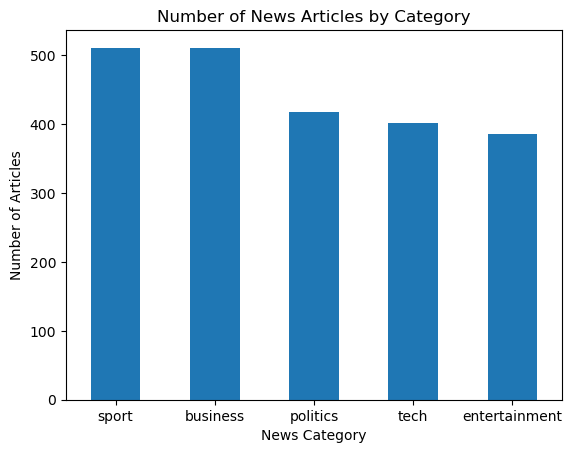

In [110]:
import matplotlib.pyplot as plt

category_counts = df['category'].value_counts()

category_counts.plot(kind='bar')

plt.title('Number of News Articles by Category')
plt.xlabel('News Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=0)
plt.show()

### Observation

The category distribution shows that Sport and Business contain the highest numbers of news articles, while Entertainment contains the lowest number. Although the five categories are not equally distributed, all categories have a substantial number of articles. Therefore, the dataset shows some class imbalance, but no single category overwhelmingly dominates the dataset.

In [111]:
category_percentages = df['category'].value_counts(normalize=True) * 100

category_percentages

category
sport            22.966292
business         22.921348
politics         18.741573
tech             18.022472
entertainment    17.348315
Name: proportion, dtype: float64

In [112]:
category_summary = pd.DataFrame({
    'Number of Articles': category_counts,
    'Percentage': category_percentages
})

category_summary

,Number of Articles,Percentage
category,,
sport,511,22.966292
business,510,22.921348
politics,417,18.741573
tech,401,18.022472
entertainment,386,17.348315


### Observation

The dataset contains five news categories with different numbers of articles. Sport has the highest representation with 511 articles (22.97%), followed closely by Business with 510 articles (22.92%). Entertainment has the lowest representation with 386 articles (17.35%). Although the categories are not equally distributed, all five categories have substantial representation in the dataset. Therefore, the dataset shows some class imbalance, but no single category overwhelmingly dominates the dataset.

In [113]:
df['word_count'] = df['text'].str.split().str.len()

df['word_count'].describe()

count    2225.000000
mean      390.295281
std       241.753128
min        90.000000
25%       250.000000
50%       337.000000
75%       479.000000
max      4492.000000
Name: word_count, dtype: float64

### Observation

The article length analysis shows considerable variation in the number of words across the 2,225 news articles. The average article contains approximately 390 words, while the median is 337 words. Article lengths range from 90 words to 4,492 words. The maximum length is considerably higher than the average, indicating that some articles are much longer than the majority of the dataset. This variation in article length is an important characteristic to consider during text preprocessing and model development.

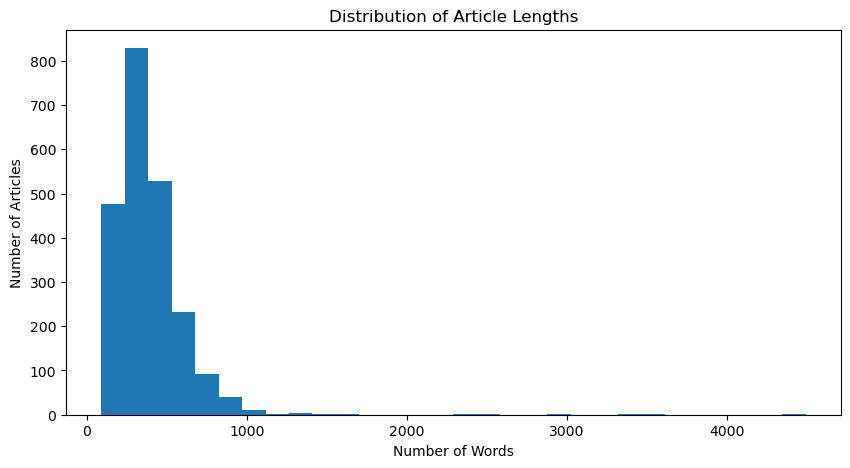

In [114]:
plt.figure(figsize=(10, 5))

plt.hist(df['word_count'], bins=30)

plt.title('Distribution of Article Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Number of Articles')

plt.show()

### Observation

The article length distribution is strongly right-skewed. Most news articles contain a relatively small number of words, while a smaller number of articles are considerably longer. The distribution has a long right tail extending beyond 4,000 words. This indicates substantial variation in article length and is consistent with the earlier descriptive statistics, where the mean article length was approximately 390 words and the maximum was 4,492 words.

In [115]:
all_text = ' '.join(df['text'].astype(str))

In [116]:
from collections import Counter
import re

words = re.findall(r'\b[a-zA-Z]+\b', all_text.lower())

word_counts = Counter(words)

word_counts.most_common(20)

[('the', 52636),
 ('to', 25113),
 ('of', 20008),
 ('and', 18611),
 ('a', 18323),
 ('in', 17725),
 ('s', 9070),
 ('for', 8945),
 ('is', 8555),
 ('that', 8257),
 ('it', 7893),
 ('on', 7625),
 ('said', 7255),
 ('was', 6028),
 ('he', 5939),
 ('be', 5805),
 ('with', 5354),
 ('as', 4981),
 ('has', 4957),
 ('have', 4772)]

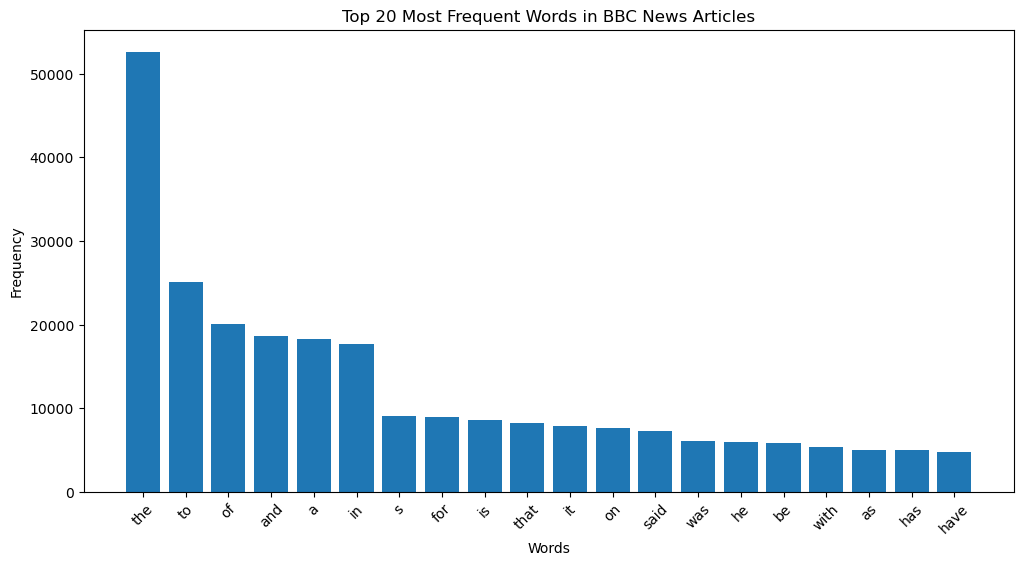

In [117]:
top_words = word_counts.most_common(20)

words_20 = [word for word, count in top_words]
counts_20 = [count for word, count in top_words]

plt.figure(figsize=(12, 6))

plt.bar(words_20, counts_20)

plt.title('Top 20 Most Frequent Words in BBC News Articles')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)

plt.show()

### Observation

The word-frequency chart shows that "the" is the most frequently occurring word in the BBC news articles, followed by other common English words such as "to", "of", "and", "a", and "in". The high frequency of these general words suggests that they may provide limited information for distinguishing between the five news categories. The frequent occurrence of "s" also indicates that some text forms may require appropriate preprocessing before feature extraction and machine learning.

In [118]:
sport_text = ' '.join(df[df['category'] == 'sport']['text'].astype(str))

sport_words = re.findall(r'\b[a-zA-Z]+\b', sport_text.lower())

sport_word_counts = Counter(sport_words)

sport_word_counts.most_common(20)

[('the', 9657),
 ('to', 4721),
 ('a', 3868),
 ('and', 3688),
 ('in', 3670),
 ('of', 2817),
 ('s', 2206),
 ('i', 1994),
 ('for', 1751),
 ('he', 1729),
 ('on', 1512),
 ('it', 1501),
 ('is', 1492),
 ('but', 1450),
 ('was', 1426),
 ('that', 1301),
 ('with', 1209),
 ('at', 1173),
 ('have', 1155),
 ('his', 1148)]

In [119]:
category_word_stats = df.groupby('category')['word_count'].agg(['mean', 'median', 'min', 'max'])

category_word_stats

,mean,median,min,max
category,,,,
business,334.186275,303.0,142,912
entertainment,337.676166,267.0,144,3570
politics,461.194245,449.0,90,4492
sport,336.322896,296.0,116,1671
tech,507.356608,450.0,165,3007


### Observation

Article length varies across the five news categories. Tech articles have the highest average length at approximately 507 words, followed by Politics at approximately 461 words. Business, Entertainment, and Sport have lower average lengths of approximately 334, 338, and 336 words respectively. Politics has the largest maximum article length at 4,492 words, while Entertainment also contains some particularly long articles. These differences show that article length varies both within and between news categories.

<Figure size 1000x600 with 0 Axes>

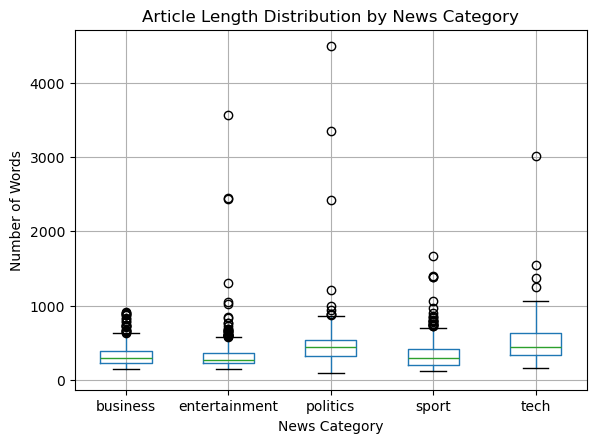

In [120]:
plt.figure(figsize=(10, 6))

df.boxplot(column='word_count', by='category')

plt.title('Article Length Distribution by News Category')
plt.suptitle('')
plt.xlabel('News Category')
plt.ylabel('Number of Words')

plt.show()

### Observation

The boxplot shows that article length varies across the five news categories. Politics and Tech generally contain longer articles than Business, Entertainment, and Sport, which is consistent with the previously calculated mean and median values. The plot also contains numerous points above the main distributions, indicating unusually long articles. Politics contains some particularly extreme values, while Entertainment and Tech also have several long articles. Overall, the visualization confirms substantial variation in article length within and between the news categories.

In [121]:
df[['category', 'text']].head(3)

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...


In [122]:
print(df.loc[0, 'text'])

tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also being built-in to high-

In [123]:
uppercase_count = df['text'].str.contains(r'[A-Z]', regex=True).sum()

print("Articles containing uppercase letters:", uppercase_count)

Articles containing uppercase letters: 0


In [124]:
punctuation_count = df['text'].str.contains(r'[^\w\s]', regex=True).sum()

print("Articles containing punctuation:", punctuation_count)

Articles containing punctuation: 2225


In [125]:
s_token_count = df['text'].str.contains(r'\bs\b', regex=True).sum()

print("Articles containing the separate 's' token:", s_token_count)

Articles containing the separate 's' token: 2065


In [126]:
import re

def clean_text(text):
    # Remove punctuation and special characters, but keep letters and numbers
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    
    # Remove the separate 's' token
    text = re.sub(r'\bs\b', ' ', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [127]:
df['clean_text'] = df['text'].apply(clean_text)

In [128]:
print("Original text:")
print(df.loc[0, 'text'])

print("\nCleaned text:")
print(df.loc[0, 'clean_text'])

Original text:
tv future in the hands of viewers with home theatre systems  plasma high-definition tvs  and digital video recorders moving into the living room  the way people watch tv will be radically different in five years  time.  that is according to an expert panel which gathered at the annual consumer electronics show in las vegas to discuss how these new technologies will impact one of our favourite pastimes. with the us leading the trend  programmes and other content will be delivered to viewers via home networks  through cable  satellite  telecoms companies  and broadband service providers to front rooms and portable devices.  one of the most talked-about technologies of ces has been digital and personal video recorders (dvr and pvr). these set-top boxes  like the us s tivo and the uk s sky+ system  allow people to record  store  play  pause and forward wind tv programmes when they want.  essentially  the technology allows for much more personalised tv. they are also being bu

In [129]:
print("Number of articles:", len(df))
print("Number of cleaned texts:", df['clean_text'].notnull().sum())

Number of articles: 2225
Number of cleaned texts: 2225


In [130]:
df[['category', 'text', 'clean_text']].head(3)

,category,text,clean_text
0,tech,tv future in the hands of viewers with home th...,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...,worldcom boss left books alone former worldcom...
2,sport,tigers wary of farrell gamble leicester say ...,tigers wary of farrell gamble leicester say th...


In [131]:
clean_all_text = ' '.join(df['clean_text'].astype(str))

clean_words = re.findall(r'\b[a-zA-Z0-9]+\b', clean_all_text.lower())

clean_word_counts = Counter(clean_words)

clean_word_counts.most_common(20)

[('the', 52636),
 ('to', 25113),
 ('of', 20008),
 ('and', 18611),
 ('a', 18323),
 ('in', 17725),
 ('for', 8945),
 ('is', 8555),
 ('that', 8257),
 ('it', 7893),
 ('on', 7625),
 ('said', 7255),
 ('was', 6028),
 ('he', 5939),
 ('be', 5805),
 ('with', 5354),
 ('as', 4981),
 ('has', 4957),
 ('have', 4772),
 ('at', 4638)]

In [132]:
X = df['clean_text']
y = df['category']

In [133]:
print("Number of input articles:", len(X))
print("Number of target labels:", len(y))

Number of input articles: 2225
Number of target labels: 2225


In [134]:
y.value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

In [135]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [136]:
print("Training articles:", len(X_train))
print("Testing articles:", len(X_test))

Training articles: 1780
Testing articles: 445


In [137]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [138]:
tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

In [139]:
X_train_tfidf = tfidf.fit_transform(X_train)

In [140]:
X_test_tfidf = tfidf.transform(X_test)

In [141]:
print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (1780, 5000)
Testing TF-IDF shape: (445, 5000)


In [142]:
from sklearn.naive_bayes import MultinomialNB

In [143]:
nb_model = MultinomialNB()

In [144]:
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [145]:
y_pred_nb = nb_model.predict(X_test_tfidf)

In [146]:
for i in range(10):
    print("Actual:", y_test.iloc[i], "| Predicted:", y_pred_nb[i])

Actual: business | Predicted: business
Actual: business | Predicted: business
Actual: entertainment | Predicted: entertainment
Actual: business | Predicted: business
Actual: business | Predicted: politics
Actual: sport | Predicted: sport
Actual: politics | Predicted: politics
Actual: politics | Predicted: politics
Actual: sport | Predicted: sport
Actual: politics | Predicted: politics


In [147]:
from sklearn.metrics import accuracy_score

nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Naïve Bayes Accuracy:", nb_accuracy)

Naïve Bayes Accuracy: 0.9887640449438202


In [148]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_nb))

               precision    recall  f1-score   support

     business       0.99      0.97      0.98       102
entertainment       0.99      0.99      0.99        77
     politics       0.97      1.00      0.98        84
        sport       1.00      1.00      1.00       102
         tech       1.00      0.99      0.99        80

     accuracy                           0.99       445
    macro avg       0.99      0.99      0.99       445
 weighted avg       0.99      0.99      0.99       445



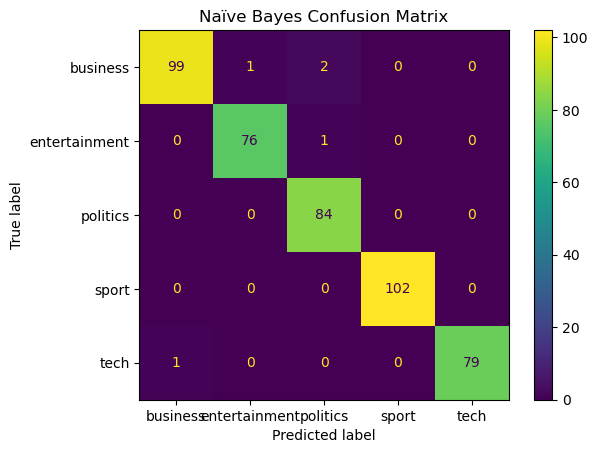

In [149]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_nb = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=nb_model.classes_
)

disp.plot()

plt.title('Naïve Bayes Confusion Matrix')
plt.show()

### Naïve Bayes Evaluation

The Multinomial Naïve Bayes model achieved an accuracy of 98.88% on the 445 test articles. The classification report shows very strong performance across all five categories, with F1-scores ranging from 0.98 to 1.00. The Sport category achieved a perfect F1-score of 1.00, while Entertainment and Tech achieved F1-scores of 0.99. Business and Politics both achieved F1-scores of 0.98.

The confusion matrix shows that most predictions lie on the main diagonal, indicating correct classifications. Only a small number of articles were misclassified, with the main errors involving Business and Politics and one Entertainment article classified as Politics. Overall, the Naïve Bayes model performed very well on the test dataset.

In [150]:
from sklearn.tree import DecisionTreeClassifier

In [151]:
dt_model = DecisionTreeClassifier(random_state=42)

In [152]:
dt_model.fit(X_train_tfidf, y_train)

DecisionTreeClassifier(random_state=42)

In [153]:
y_pred_dt = dt_model.predict(X_test_tfidf)

In [154]:
for i in range(10):
    print("Actual:", y_test.iloc[i], "| Predicted:", y_pred_dt[i])

Actual: business | Predicted: business
Actual: business | Predicted: business
Actual: entertainment | Predicted: entertainment
Actual: business | Predicted: politics
Actual: business | Predicted: politics
Actual: sport | Predicted: sport
Actual: politics | Predicted: politics
Actual: politics | Predicted: politics
Actual: sport | Predicted: sport
Actual: politics | Predicted: politics


In [155]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8449438202247191


In [156]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

               precision    recall  f1-score   support

     business       0.88      0.75      0.81       102
entertainment       0.81      0.82      0.81        77
     politics       0.80      0.88      0.84        84
        sport       0.87      0.92      0.90       102
         tech       0.86      0.86      0.86        80

     accuracy                           0.84       445
    macro avg       0.84      0.85      0.84       445
 weighted avg       0.85      0.84      0.84       445



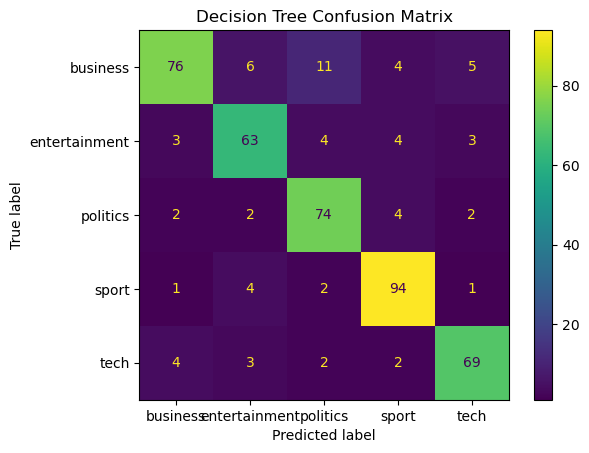

In [157]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_dt = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=dt_model.classes_
)

disp.plot()

plt.title('Decision Tree Confusion Matrix')
plt.show()

## Initial Model Comparison

Two machine learning models were trained and evaluated using the same training and testing datasets and the same TF-IDF features.

| Model | Accuracy | Macro F1-score | Weighted F1-score |
|---|---:|---:|---:|
| Naïve Bayes | 98.88% | 0.99 | 0.99 |
| Decision Tree | 84.49% | 0.84 | 0.84 |

Naïve Bayes performed substantially better than the Decision Tree on the test dataset. It achieved an accuracy of 98.88%, compared with 84.49% for the Decision Tree. The F1-scores also show the same pattern, with Naïve Bayes achieving approximately 0.99 compared with approximately 0.84 for the Decision Tree.

The confusion matrix of the Decision Tree shows more misclassifications across the categories, particularly between Business and Politics. In contrast, the Naïve Bayes confusion matrix contained only a small number of misclassifications.

In [158]:
MultinomialNB()

MultinomialNB()

In [159]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB

In [160]:
nb_param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]
}

In [161]:
nb_grid = GridSearchCV(
    MultinomialNB(),
    param_grid=nb_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

In [162]:
nb_grid.fit(X_train_tfidf, y_train)

GridSearchCV(cv=5, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]},
             scoring='f1_macro')

In [163]:
print("Best parameters:", nb_grid.best_params_)
print("Best cross-validation F1-score:", nb_grid.best_score_)

Best parameters: {'alpha': 0.5}
Best cross-validation F1-score: 0.9724398611492895


In [164]:
nb_results = pd.DataFrame(nb_grid.cv_results_)

nb_results[['param_alpha', 'mean_test_score', 'rank_test_score']]

,param_alpha,mean_test_score,rank_test_score
0,0.01,0.969554,4
1,0.10,0.971156,2
2,0.50,0.972440,1
3,1.00,0.970844,3
4,2.00,0.967898,5


In [165]:
best_nb_model = nb_grid.best_estimator_

In [166]:
y_pred_nb_tuned = best_nb_model.predict(X_test_tfidf)

In [167]:
nb_tuned_accuracy = accuracy_score(y_test, y_pred_nb_tuned)

print("Tuned Naïve Bayes Accuracy:", nb_tuned_accuracy)

Tuned Naïve Bayes Accuracy: 0.9842696629213483


In [168]:
print(classification_report(y_test, y_pred_nb_tuned))

               precision    recall  f1-score   support

     business       0.99      0.96      0.98       102
entertainment       0.97      0.99      0.98        77
     politics       0.97      0.99      0.98        84
        sport       1.00      1.00      1.00       102
         tech       0.99      0.99      0.99        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445



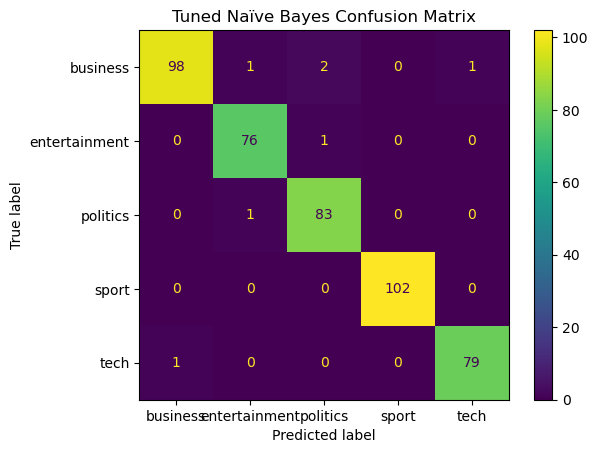

In [169]:
cm_nb_tuned = confusion_matrix(y_test, y_pred_nb_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb_tuned,
    display_labels=best_nb_model.classes_
)

disp.plot()

plt.title('Tuned Naïve Bayes Confusion Matrix')
plt.show()

In [170]:
dt_param_grid = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [171]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

In [172]:
dt_grid.fit(X_train_tfidf, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='f1_macro')

In [173]:
print("Best Decision Tree parameters:", dt_grid.best_params_)
print("Best cross-validation F1-score:", dt_grid.best_score_)

Best Decision Tree parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best cross-validation F1-score: 0.8050792173470434


In [174]:
dt_results = pd.DataFrame(dt_grid.cv_results_)

dt_results[
    [
        'param_max_depth',
        'param_min_samples_split',
        'param_min_samples_leaf',
        'mean_test_score',
        'rank_test_score'
    ]
].sort_values('rank_test_score').head(10)

,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_score,rank_test_score
31,None,5,2,0.805079,1
18,30,2,1,0.803654,2
22,30,5,2,0.801745,3
21,30,2,2,0.799779,4
30,None,2,2,0.797083,5
19,30,5,1,0.796160,6
29,None,10,1,0.795680,7
27,None,2,1,0.795212,8
28,None,5,1,0.794440,9
23,30,10,2,0.794187,10


The tuned Decision Tree's best cross-validation F1 = 0.8051, which is only slightly below its baseline test F1 of about 0.84. But we cannot compare CV F1 directly with test F1 and conclude that tuning made it worse.

In [175]:
best_dt_model = dt_grid.best_estimator_

In [176]:
y_pred_dt_tuned = best_dt_model.predict(X_test_tfidf)

In [177]:
dt_tuned_accuracy = accuracy_score(y_test, y_pred_dt_tuned)

print("Tuned Decision Tree Accuracy:", dt_tuned_accuracy)

Tuned Decision Tree Accuracy: 0.8471910112359551


In [178]:
print(classification_report(y_test, y_pred_dt_tuned))

               precision    recall  f1-score   support

     business       0.86      0.77      0.81       102
entertainment       0.85      0.82      0.83        77
     politics       0.79      0.86      0.82        84
        sport       0.87      0.94      0.91       102
         tech       0.86      0.84      0.85        80

     accuracy                           0.85       445
    macro avg       0.85      0.85      0.85       445
 weighted avg       0.85      0.85      0.85       445



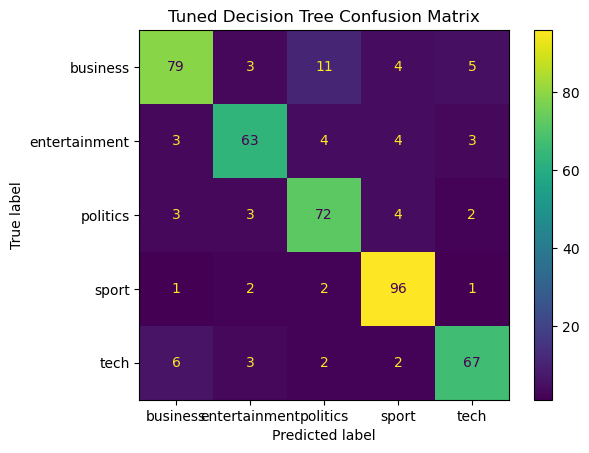

In [179]:
cm_dt_tuned = confusion_matrix(y_test, y_pred_dt_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt_tuned,
    display_labels=best_dt_model.classes_
)

disp.plot()

plt.title('Tuned Decision Tree Confusion Matrix')
plt.show()

## Final Model Comparison

Four model configurations were evaluated using the same test dataset of 445 news articles.

| Model | Version | Test Accuracy | Macro F1-score |
|---|---|---:|---:|
| Naïve Bayes | Baseline | 98.88% | 0.99 |
| Naïve Bayes | Tuned (alpha = 0.5) | 98.43% | 0.98 |
| Decision Tree | Baseline | 84.49% | 0.84 |
| Decision Tree | Tuned | 84.72% | 0.85 |

The baseline Naïve Bayes model achieved the highest test accuracy of 98.88% and the highest Macro F1-score of approximately 0.99. The tuned Naïve Bayes model performed slightly lower on the test dataset, despite achieving the highest cross-validation score during hyperparameter tuning.

For the Decision Tree, hyperparameter tuning resulted in a small improvement in test accuracy from 84.49% to 84.72%, with the Macro F1-score increasing from approximately 0.84 to 0.85.

Overall, the baseline Naïve Bayes model performed substantially better than both the baseline and tuned Decision Tree models. Therefore, based on the test-set performance, Naïve Bayes is selected as the final classification model.

In [180]:
new_articles = [
    "The football team secured a dramatic victory after scoring a late goal in the championship match.",
    
    "The government announced new plans for parliament and changes to national economic policy.",
    
    "The company reported strong financial results and announced plans to expand its business operations.",
    
    "The latest smartphone technology includes a faster processor, improved artificial intelligence features and a new display.",
    
    "The actor is preparing for a new film while the movie studio announced several upcoming entertainment releases."
]

In [181]:
X_train_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 206507 stored elements and shape (1780, 5000)>

In [183]:
new_articles_tfidf = tfidf.transform(new_articles)

In [184]:
new_predictions = nb_model.predict(new_articles_tfidf)

In [185]:
for article, prediction in zip(new_articles, new_predictions):
    print("Article:", article)
    print("Predicted category:", prediction)
    print("-" * 80)

Article: The football team secured a dramatic victory after scoring a late goal in the championship match.
Predicted category: sport
--------------------------------------------------------------------------------
Article: The government announced new plans for parliament and changes to national economic policy.
Predicted category: politics
--------------------------------------------------------------------------------
Article: The company reported strong financial results and announced plans to expand its business operations.
Predicted category: business
--------------------------------------------------------------------------------
Article: The latest smartphone technology includes a faster processor, improved artificial intelligence features and a new display.
Predicted category: tech
--------------------------------------------------------------------------------
Article: The actor is preparing for a new film while the movie studio announced several upcoming entertainment release

## Final Results Summary

The BBC News classification project evaluated two machine learning algorithms: Multinomial Naïve Bayes and Decision Tree.

The dataset contained 2,225 news articles belonging to five categories: Business, Entertainment, Politics, Sport, and Tech. The dataset was divided into 80% training data and 20% testing data, resulting in 1,780 training articles and 445 testing articles.

TF-IDF was used to convert the cleaned news article text into numerical features. Both models were trained using the same TF-IDF representation and evaluated using the same test dataset.

### Model Performance

| Model | Version | Test Accuracy | Macro F1-score |
|---|---|---:|---:|
| Naïve Bayes | Baseline | 98.88% | 0.99 |
| Naïve Bayes | Tuned (alpha = 0.5) | 98.43% | 0.98 |
| Decision Tree | Baseline | 84.49% | 0.84 |
| Decision Tree | Tuned | 84.72% | 0.85 |

The baseline Multinomial Naïve Bayes model achieved the highest test accuracy of 98.88% and the highest Macro F1-score of approximately 0.99. Therefore, the baseline Naïve Bayes model was selected as the final model.

Hyperparameter tuning improved the Decision Tree slightly from 84.49% to 84.72%. However, tuning the Naïve Bayes model did not improve its test performance, with accuracy decreasing slightly from 98.88% to 98.43%.

The final Naïve Bayes model was also tested on five new unseen news article examples. It predicted the articles as Sport, Politics, Business, Tech, and Entertainment respectively.

## Discussion of Results

The experimental results show that Multinomial Naïve Bayes performed substantially better than the Decision Tree for classifying BBC News articles. The baseline Naïve Bayes model achieved an accuracy of 98.88% and a Macro F1-score of approximately 0.99, while the baseline Decision Tree achieved an accuracy of 84.49% and a Macro F1-score of approximately 0.84.

The strong performance of Naïve Bayes indicates that the TF-IDF representation was effective for this text classification task. The model was able to distinguish the five news categories with only a small number of misclassifications. In the baseline evaluation, the Sport category achieved a precision, recall, and F1-score of 1.00.

The Decision Tree produced more classification errors across the five categories. Its confusion matrix showed noticeable confusion between categories, particularly between Business and Politics. Hyperparameter tuning produced a small improvement in the Decision Tree, increasing its test accuracy from 84.49% to 84.72%.

For Naïve Bayes, hyperparameter tuning selected an alpha value of 0.5 based on five-fold cross-validation. However, the tuned model achieved 98.43% accuracy on the test dataset, which was slightly lower than the baseline model's 98.88% accuracy. Therefore, the baseline Naïve Bayes model was selected as the final model based on its test-set performance.

Overall, the results demonstrate that Naïve Bayes was the most effective of the evaluated models for this BBC News text classification problem.

## Limitations and Possible Improvements

Although the final Naïve Bayes model achieved very high classification performance, there are several limitations to the current approach.

First, the dataset contains a fixed collection of BBC News articles from the provided dataset. Therefore, the model's performance may not necessarily represent its performance on completely different news sources or newer articles.

Second, the project used TF-IDF to represent the article text. TF-IDF captures the importance of words within the documents, but it does not fully represent the deeper meaning or context of sentences.

Third, only two machine learning algorithms were evaluated in this project: Multinomial Naïve Bayes and Decision Tree. Other classification algorithms could potentially be investigated and compared in future work.

Fourth, hyperparameter tuning was performed for both models using the selected parameter ranges. A wider search could potentially identify other parameter combinations, although this would require additional computational resources.

Finally, the new article prediction demonstration used manually created example articles. A larger collection of genuinely unseen articles could provide a more extensive evaluation of the model's ability to classify new content.

### Possible Improvements

Future improvements could include using additional machine learning algorithms, experimenting with different text representation techniques, expanding the dataset, and evaluating the final model on a larger collection of unseen news articles.

## Conclusion

This project developed a machine learning system for automatically classifying BBC News articles into five categories: Business, Entertainment, Politics, Sport, and Tech. The provided dataset contained 2,225 articles, which were divided into training and testing sets.

The article text was explored and cleaned before being converted into numerical features using TF-IDF. Two machine learning algorithms, Multinomial Naïve Bayes and Decision Tree, were trained and evaluated using the same test dataset.

The baseline Multinomial Naïve Bayes model achieved the best overall performance, with a test accuracy of 98.88% and a Macro F1-score of approximately 0.99. The Decision Tree achieved a lower accuracy of 84.49%. Hyperparameter tuning produced a small improvement for the Decision Tree, increasing its accuracy to 84.72%, while the tuned Naïve Bayes model achieved 98.43% accuracy on the test set.

Based on the evaluation results, the baseline Multinomial Naïve Bayes model was selected as the final model. The model was also successfully tested on five new unseen article examples and correctly predicted their categories as Sport, Politics, Business, Tech, and Entertainment.

Overall, the project demonstrates that machine learning combined with TF-IDF text representation can effectively classify news articles into predefined categories, with Multinomial Naïve Bayes providing particularly strong performance on the provided BBC News dataset.

In [186]:
new_articles_tfidf = tfidf.transform(new_articles)

new_predictions = nb_model.predict(new_articles_tfidf)

for article, prediction in zip(new_articles, new_predictions):
    print("Article:", article)
    print("Predicted category:", prediction)
    print("-" * 80)

Article: The football team secured a dramatic victory after scoring a late goal in the championship match.
Predicted category: sport
--------------------------------------------------------------------------------
Article: The government announced new plans for parliament and changes to national economic policy.
Predicted category: politics
--------------------------------------------------------------------------------
Article: The company reported strong financial results and announced plans to expand its business operations.
Predicted category: business
--------------------------------------------------------------------------------
Article: The latest smartphone technology includes a faster processor, improved artificial intelligence features and a new display.
Predicted category: tech
--------------------------------------------------------------------------------
Article: The actor is preparing for a new film while the movie studio announced several upcoming entertainment release

## Final Model Prediction Demonstration

In [188]:
test_articles = [
   "The tennis player defeated his opponent in a thrilling final after winning three consecutive sets.",

    "The finance ministry announced new measures to reduce inflation and support economic growth.",

    "The singer announced a world tour following the release of her latest album.",

    "Researchers developed a new computer chip designed to improve the performance of artificial intelligence systems.",

    "The national football club appointed a new manager ahead of the upcoming international tournament.",

    "The parliament approved a new bill after several weeks of political debate.",

    "The company reported record sales this year and plans to open several new offices.",

    "The streaming service announced several new television series and movies for its subscribers.",

    "Scientists unveiled a new software system that can process large amounts of data more efficiently.",

    "The cricket team secured a convincing victory after scoring a high total in the final match."
]

test_articles_tfidf = tfidf.transform(test_articles)

test_predictions = nb_model.predict(test_articles_tfidf)

for article, prediction in zip(test_articles, test_predictions):
    print("Article:", article)
    print("Predicted Category:", prediction)
    print("-" * 80)

Article: The tennis player defeated his opponent in a thrilling final after winning three consecutive sets.
Predicted Category: sport
--------------------------------------------------------------------------------
Article: The finance ministry announced new measures to reduce inflation and support economic growth.
Predicted Category: business
--------------------------------------------------------------------------------
Article: The singer announced a world tour following the release of her latest album.
Predicted Category: entertainment
--------------------------------------------------------------------------------
Article: Researchers developed a new computer chip designed to improve the performance of artificial intelligence systems.
Predicted Category: tech
--------------------------------------------------------------------------------
Article: The national football club appointed a new manager ahead of the upcoming international tournament.
Predicted Category: sport
---------

In [189]:
probabilities = nb_model.predict_proba(test_articles_tfidf)

for article, probs in zip(test_articles, probabilities):
    print(article)
    for category, probability in zip(nb_model.classes_, probs):
        print(category, "=", probability)
    print()

The tennis player defeated his opponent in a thrilling final after winning three consecutive sets.
business = 0.050507379842591876
entertainment = 0.06464321021686553
politics = 0.043846483889522704
sport = 0.7822073420869619
tech = 0.05879558396405665

The finance ministry announced new measures to reduce inflation and support economic growth.
business = 0.7933509436204362
entertainment = 0.022876814090272514
politics = 0.13082020490110505
sport = 0.016433527635516466
tech = 0.03651850975266938

The singer announced a world tour following the release of her latest album.
business = 0.07171278605200287
entertainment = 0.7203915909434773
politics = 0.048820540643481736
sport = 0.07338669628100625
tech = 0.08568838608003147

Researchers developed a new computer chip designed to improve the performance of artificial intelligence systems.
business = 0.09657618161338374
entertainment = 0.06753895849044
politics = 0.09599704106391709
sport = 0.06698127017351813
tech = 0.6729065486587397

The

In [190]:
test_article = [
    "The government introduced new tax policies that will affect companies, businesses, investors and financial markets."
]

# Convert the article using the same TF-IDF vectorizer
test_article_tfidf = tfidf.transform(test_article)

# Get probabilities from the trained Naïve Bayes model
probabilities = nb_model.predict_proba(test_article_tfidf)[0]

# Display probabilities for each category
for category, probability in zip(nb_model.classes_, probabilities):
    print(f"{category}: {probability:.4f}")

# Display the final prediction
prediction = nb_model.predict(test_article_tfidf)[0]

print("\nFinal Prediction:", prediction)

business: 0.7891
entertainment: 0.0217
politics: 0.1335
sport: 0.0142
tech: 0.0416

Final Prediction: business


In [191]:
import numpy as np

# Artificial probabilities for one article
# Business and Politics have exactly the same probability
fake_probabilities = np.array([
    0.48,   # business
    0.02,   # entertainment
    0.48,   # politics
    0.01,   # sport
    0.01    # tech
])

# Categories in the same order
categories = nb_model.classes_

print("Categories:", categories)
print("Probabilities:", fake_probabilities)

# Find the category/categories with the highest probability
max_probability = fake_probabilities.max()

tied_categories = categories[fake_probabilities == max_probability]

print("\nHighest probability:", max_probability)
print("Category/categories with highest probability:", tied_categories)

Categories: ['business' 'entertainment' 'politics' 'sport' 'tech']
Probabilities: [0.48 0.02 0.48 0.01 0.01]

Highest probability: 0.48
Category/categories with highest probability: ['business' 'politics']
